<h1> Hands on: TDDFT with <span style="color: red;">QE</span>py</h1>

#### Real-time TDDFT (ce-tddft) on a periodic cell: FCC aluminum


## To run this tutorial we need to
 - import QEpy
 - build the QE input for a 4-atom Al cell and write it to `qe_in.in`
 - run SCF, then real-time TDDFT reading the same file

In [ ]:
# --- optional pip installs (normally leave collapsed / do not run) ---
!tddft=yes pip install qepy f90wrap==0.2.16
!pip install dftpy
!pip install matplotlib

In [1]:
import os
import qepy
from qepy.driver import Driver
from qepy.io import QEInput
import numpy as np
import matplotlib.pyplot as plt

## Generate the QE options to build the input file

In [2]:
prefix = 'tmp'
outdir = './'     # prefix='tmp' + outdir='./'  ->  ground state saved in ./tmp.save

In [4]:
qe_options = {}

qe_options['&control'] = {}
qe_options['&control']['calculation'] = 'scf'
qe_options['&control']['prefix'] = prefix
qe_options['&control']['restart_mode'] = 'from_scratch'
qe_options['&control']['outdir'] = outdir
qe_options['&control']['pseudo_dir'] = './data'
qe_options['&control']['tprnfor'] = True
qe_options['&control']['tstress'] = True

qe_options['&system'] = {}
qe_options['&system']['ibrav'] = 0
qe_options['&system']['nat'] = 4
qe_options['&system']['ntyp'] = 1
qe_options['&system']['ecutwfc'] = 40
qe_options['&system']['occupations'] = 'smearing'
qe_options['&system']['smearing'] = 'gaussian'
qe_options['&system']['degauss'] = 0.001
qe_options['&system']['nosym'] = True

qe_options['&electrons'] = {}
qe_options['&electrons']['conv_thr'] = 1e-8
qe_options['&electrons']['mixing_beta'] = 0.7
qe_options['&electrons']['electron_maxstep'] = 200

qe_options['atomic_species'] = ['Al  26.9815  Al_ONCV_PBE-1.2.upf']

qe_options['cell_parameters angstrom'] = [
    '4.0500001907  0.0000000000  0.0000000000',
    '0.0000000000  4.0500001907  0.0000000000',
    '0.0000000000  0.0000000000  4.0500001907',
]

qe_options['atomic_positions angstrom'] = [
    'Al  0.200000000  0.000000000  0.000000000',
    'Al  2.025000095  2.025000095  0.000000000',
    'Al  2.025000095  0.000000000  2.025000095',
    'Al  0.000000000  2.025000095  2.025000095',
]

# NOT gamma: ce-tddft aborts on gamma_only, so use a 1x1x1 grid
qe_options['k_points automatic'] = ['1 1 1 0 0 0']

## Add the real-time TDDFT (`&inputtddft`) parameters

In [5]:
qe_options['&inputtddft'] = {}
qe_options['&inputtddft']['job'] = 'optical'
qe_options['&inputtddft']['prefix'] = prefix
qe_options['&inputtddft']['tmp_dir'] = outdir          # must match the SCF outdir
qe_options['&inputtddft']['dt'] = 1.0                  # time step in attoseconds
qe_options['&inputtddft']['nstep'] = 2000              # # of steps (their quick test used 10)
qe_options['&inputtddft']['e_direction'] = 1           # kick polarization: 1/2/3 = x/y/z

## Workflow for SCF

 1. Initialize QEpy `Driver` class from the input file
 2. Run SCF
 3. Save wavefunction and eigenvalues data

## Step 1: Initialize the Driver class from the input file

In [7]:
driver = Driver(qe_options=qe_options, task='scf', logfile=prefix+'.scf.out')

## Step 2: Run a scf calculation

In [8]:
driver.scf()

-552.9347738996563

## Step 3: Save the wavefunction for the follow-up TDDFT calculation

In [9]:
driver.save()
driver.stop()          # finalize the SCF driver so the .save is fully flushed

# Real-time TDDFT of the Al cell

 1. Initialize the optical driver from the same input file
 2. Propagate in real time and collect the dipole
 3. Analyze data (plot the response)

## Step 1: Initialize the Driver class for the optical (ce-tddft) run

In [15]:
driver_td = Driver(qe_options=qe_options, task='optical',
                   iterative=True, logfile=prefix+'.tddft.out')

## Step 2: Propagate in real time and collect the dipole

In [11]:
nstep = qe_options['&inputtddft']['nstep']
mu_t = np.zeros((nstep, 3))
for i in range(nstep):
    driver_td.diagonalize()                                    # advance one real-time step
    mu_t[i] = np.asarray(driver_td.get_dipole_tddft()).ravel() # dipole (3,1) -> (3,)

In [12]:
driver_td.stop()

# Step 3: Plot the real-time response 

In [13]:
# Fourier-transform the dipole response. ce-tddft's dt is in attoseconds, so
# ATTO=1e-18 converts to seconds and EV_J/HBAR puts E*t dimensionless in sin(E*t).
dt = qe_options['&inputtddft']['dt']
e_strength, damping = 0.01, 0.02
ATTO, EV_J, HBAR = 1e-18, 1.602176634e-19, 1.054571817e-34

mu = mu_t[:, 0] - mu_t[0, 0]                        # x-component response (e_direction = 1)
t  = np.arange(mu.size) * dt * ATTO * EV_J / HBAR   # -> inverse-eV time
w  = np.exp(-t**2 * damping)

E = np.linspace(0, 20, 2000)                        # eV
S = np.array([np.sum(mu * w * np.sin(e * t)) * e for e in E])
S *= 2 * dt * ATTO * EV_J / HBAR / (e_strength * np.pi)

(0.0, 20.0)

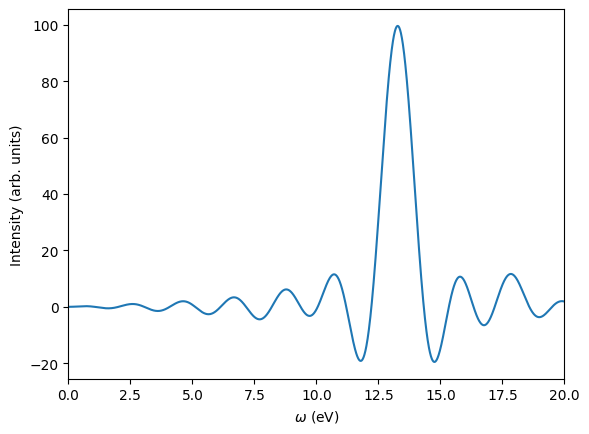

In [14]:
plt.plot(E, S)
plt.xlabel(r'$\omega$ (eV)')
plt.ylabel(r'Intensity (arb. units)')
plt.xlim([0,20])